## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [1]:
!pip install faiss-cpu sentence-transformers matplotlib seaborn

In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mini corpus
docs = [
    "AI helps optimize solar energy production",
    "Machine learning predicts rainfall patterns",
    "AI detects water pollution using sensors",
    "Climate change affects agriculture",
    "Deep learning improves wind energy forecasting",
    "Neural networks optimize irrigation systems",
    "AI monitors air quality in cities",
    "Satellite images help track deforestation",
    "AI reduces industrial energy consumption",
    "Renewable energy demand is increasing"
]

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(docs)

# Create FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

# Add vectors
index.add(np.array(embeddings))

print("Total vectors:", index.ntotal)

# Query
query = "How does AI help detect pollution?"
query_embedding = model.encode([query])

# Search top-k
k = 3
distances, indices = index.search(np.array(query_embedding), k)

print("Top matches:")
for i, idx in enumerate(indices[0]):
    print(f"{i+1}: {docs[idx]} | Distance: {distances[0][i]}")

c:\Users\mohit\Documents\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1612.35it/s]


Total vectors: 10
Top matches:
1: AI detects water pollution using sensors | Distance: 0.41058602929115295
2: AI monitors air quality in cities | Distance: 0.5702016353607178
3: AI reduces industrial energy consumption | Distance: 1.0398166179656982


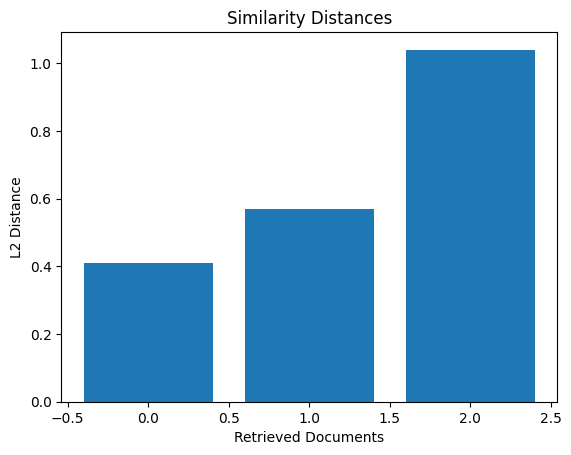

In [3]:
plt.bar(range(k), distances[0])
plt.xlabel("Retrieved Documents")
plt.ylabel("L2 Distance")
plt.title("Similarity Distances")
plt.show()

L2 measures absolute distance.
Cosine measures angular similarity.
Normalized embeddings make cosine more effective.

## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [4]:
!pip install chromadb sentence-transformers

In [5]:
import chromadb

client = chromadb.Client()

collection = client.create_collection("ai_water_docs")

docs = [
    "AI detects pollution in rivers",
    "Sensors monitor water quality",
    "Deep learning predicts floods",
    "AI helps conserve marine ecosystems",
    "Machine learning tracks groundwater levels",
    "AI identifies plastic waste in oceans",
    "Smart irrigation saves water",
    "AI predicts drought conditions",
    "Water recycling improves sustainability",
    "AI monitors drinking water safety"
]

metadatas = [
    {"title": f"Doc{i}", "source": "scientific"} for i in range(len(docs))
]

ids = [str(i) for i in range(len(docs))]

collection.add(
    documents=docs,
    metadatas=metadatas,
    ids=ids
)

results = collection.query(
    query_texts=["How does AI detect pollution?"],
    n_results=3
)

print(results)

{'ids': [['0', '5', '3']], 'embeddings': None, 'documents': [['AI detects pollution in rivers', 'AI identifies plastic waste in oceans', 'AI helps conserve marine ecosystems']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'source': 'scientific', 'title': 'Doc0'}, {'title': 'Doc5', 'source': 'scientific'}, {'title': 'Doc3', 'source': 'scientific'}]], 'distances': [[0.35192418098449707, 0.9500423073768616, 0.9539693593978882]]}


In [6]:
results = collection.query(
    query_texts=["water quality"],
    n_results=3,
    where={"source": "scientific"}
)

print(results)

{'ids': [['1', '8', '0']], 'embeddings': None, 'documents': [['Sensors monitor water quality', 'Water recycling improves sustainability', 'AI detects pollution in rivers']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'source': 'scientific', 'title': 'Doc1'}, {'title': 'Doc8', 'source': 'scientific'}, {'source': 'scientific', 'title': 'Doc0'}]], 'distances': [[0.5844347476959229, 1.0345659255981445, 1.054213285446167]]}


Chroma does NOT automatically deduplicate unless IDs are same.

## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [7]:
!pip install pinecone sentence-transformers

In [10]:
!pip install python-dotenv

In [11]:
import os
from dotenv import load_dotenv
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer

load_dotenv()

api_key = os.getenv("PINECONE_API_KEY")

pc = Pinecone(api_key=api_key)

index_name = "student-demo"

if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )

index = pc.Index(index_name)

model = SentenceTransformer("all-MiniLM-L6-v2")

docs = [f"Document {i}" for i in range(50)]
embeddings = model.encode(docs)

vectors = [
    (str(i), embeddings[i].tolist(), {"text": docs[i]})
    for i in range(len(docs))
]

index.upsert(vectors=vectors)

query = "Find AI environment related docs"
query_vector = model.encode(query).tolist()

results = index.query(
    vector=query_vector,
    top_k=3,
    include_metadata=True
)

print(results)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 604.11it/s]


QueryResponse(matches=[ScoredVector(id='cloud_doc_1', score=0.2666502, values=[], metadata={'text': 'Pinecone allows for highly scalable cloud vector search.'}), ScoredVector(id='24', score=0.258112907, values=[], metadata={'text': 'Document 24'}), ScoredVector(id='11', score=0.24464035, values=[], metadata={'text': 'Document 11'})], namespace='', usage=Usage(read_units=1, write_units=None), response_info=ResponseInfo(raw_headers={'date': 'Wed, 24 Jun 2026 10:44:35 GMT', 'content-type': 'application/json', 'content-length': '350', 'connection': 'keep-alive', 'x-pinecone-max-indexed-lsn': '3', 'x-pinecone-request-latency-ms': '92', 'x-envoy-upstream-service-time': '91', 'x-pinecone-response-duration-ms': '94', 'grpc-status': '0', 'server': 'envoy'}))


| Feature     | FAISS         | Pinecone               |
| ----------- | ------------- | ---------------------- |
| Speed       | Faster local  | Slight network latency |
| Setup       | Easy          | API required           |
| Scalability | Limited local | Highly scalable        |
| Cost        | Free          | Free tier limited      |
| Persistence | Manual        | Managed                |


FAISS is faster because it runs entirely on the local machine without network communication. Query time is usually very low since vectors are stored in memory or local disk.

Pinecone introduces network latency because the query must travel to the cloud server, be processed, and return results. This makes it slightly slower than FAISS.

A managed vector database like Pinecone provides:

automatic scaling for millions of vectors
persistence without manual saving
high availability
cloud deployment
metadata filtering
easier production deployment
distributed infrastructure
no need to manage storage manually

FAISS is good for experimentation, while Pinecone is better for production systems.

### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters

Semantic search retrieves documents based on meaning, while BM25 retrieves based on exact keywords.

Hybrid search usually performs better because:

BM25 gives exact matches
Vector search gives semantic matches

This balances precision and recall.

Before indexing:

Milvus performs brute-force search, which is slower.

After IVF/HNSW indexing:

Search becomes much faster because it avoids scanning all vectors.


Approximate Nearest Neighbor (ANN) reduces search complexity by trading small accuracy loss for huge speed improvements.

Useful for large datasets.

Without filtering:

The system retrieves based only on semantic similarity.

With filtering:

The system narrows results based on metadata constraints.


Metadata filtering allows context-aware retrieval.

Examples:

source = scientific
year > 2022
author = NASA

This makes retrieval more targeted and production-ready.

